In [113]:
import os
os.environ["OMP_NUM_THREADS"] = "6"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [114]:
from sqlalchemy import create_engine
import urllib

# Configura la conexión
from dotenv import load_dotenv
import os

load_dotenv() # busca ".env" en el directorio actual (o directorios superiores) y carga sus variables

server = os.environ.get('DB_SERVER')
database = os.environ.get('DB_NAME')
username = os.environ.get('DB_USER')
password = os.environ.get('DB_PASSWORD')

driver = 'ODBC Driver 17 for SQL Server'  # Verifica que tengas este driver instalado

params = urllib.parse.quote_plus(
    f'DRIVER={{{driver}}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'UID={username};'
    f'PWD={password}'
)


In [115]:

engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

query = "SELECT [plate],[AvgMinutes],[TotalAmount],[LM60]+[LM120] [LM120], [LT60]+[LT120] [LT120],[LM320]+[LT320] [L320],[LMRest]+[LTRest] [LRest],[F60]+[F120]+[F320]+[FRest] [FT],[Age],[Tag],[DigTrans] FROM [ESPDM].[dbo].[ParkingTransSummaryEnriched] where [IDPK] = 'PKSA' and [NTrans] > 5"

df = pd.read_sql(query, engine)

# print(df.head())


In [116]:
df.describe()

,AvgMinutes,TotalAmount,LM120,LT120,L320,LRest,FT,Age,Tag,DigTrans
count,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000
mean,116.388381,33.868414,3.089514,4.221045,2.658020,0.353307,0.111801,12.990607,2.625868,0.377055
std,127.137287,34.610168,3.940580,4.789932,3.389759,1.362530,0.392635,7.086209,0.894854,5.762695
min,6.000000,5.250000,0.000000,0.000000,0.000000,0.000000,0.000000,1.250000,0.000000,0.000000
25%,68.000000,16.650000,1.000000,2.000000,1.000000,0.000000,0.000000,7.090000,2.000000,0.000000
50%,92.000000,24.750000,2.000000,3.000000,2.000000,0.000000,0.000000,12.080000,3.000000,0.000000
75%,129.000000,38.450000,4.000000,5.000000,4.000000,0.000000,0.000000,19.250000,3.000000,0.000000
max,3097.000000,672.200000,68.000000,67.000000,46.000000,34.000000,5.000000,25.830000,4.000000,271.000000


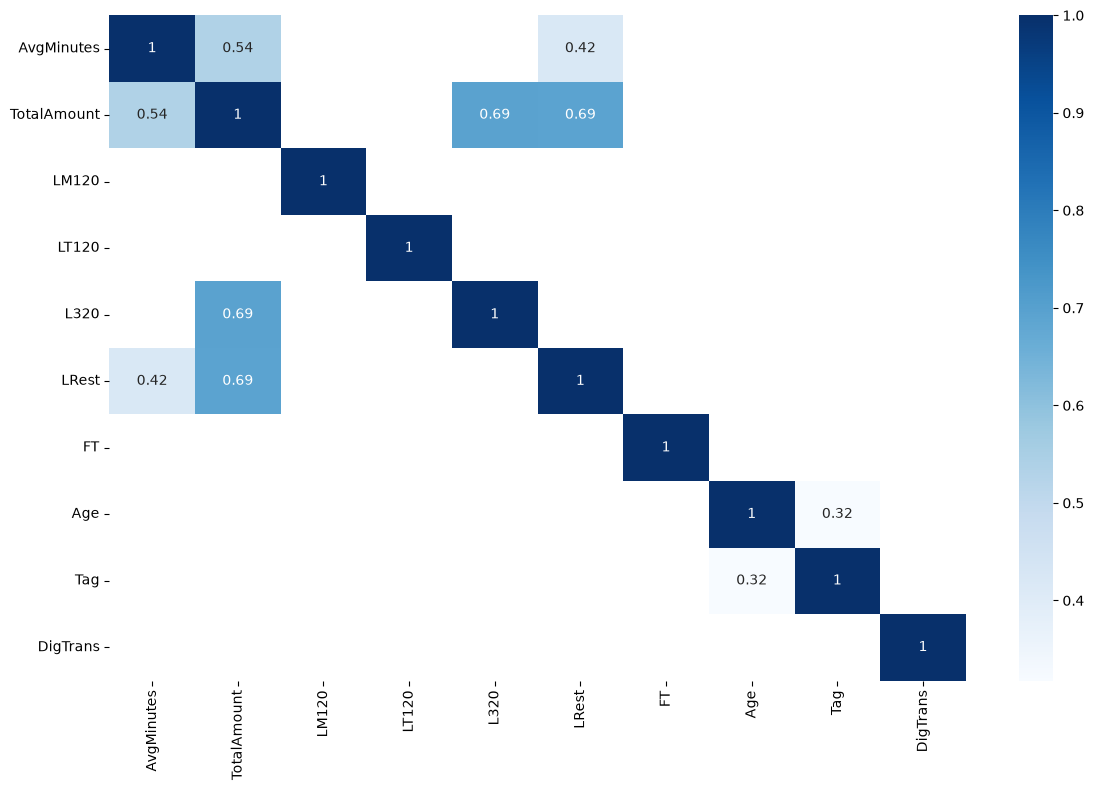

In [117]:
correlations = df.drop('plate', axis=1).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(correlations[(correlations > 0.30) | (correlations < -0.30)],
            cmap='Blues', annot=True, ax=ax)

plt.tight_layout()
plt.show()

C:\Users\jframirez\AppData\Local\Temp\ipykernel_38324\533375319.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.drop('plate', axis=1).hist(ax=ax)


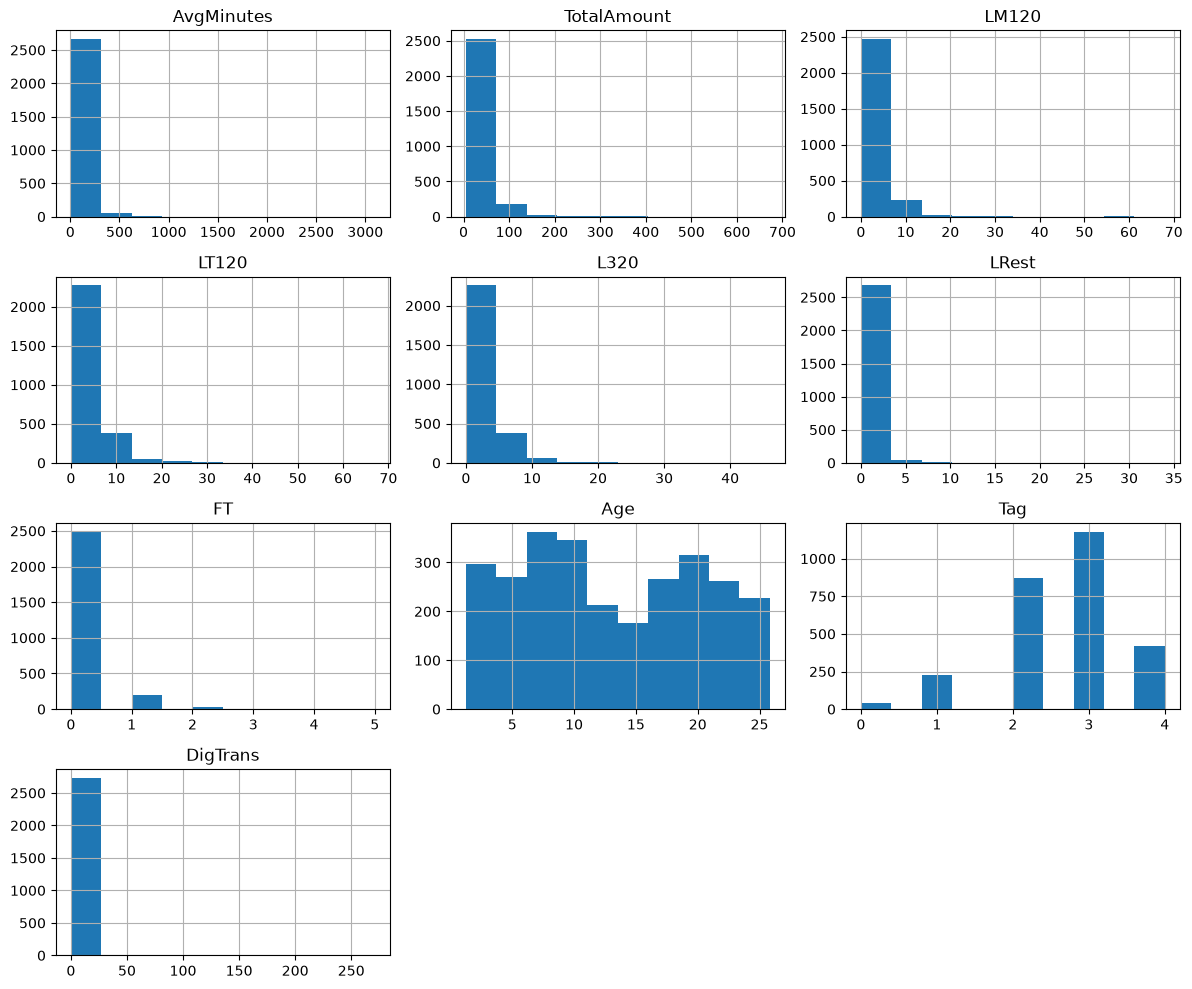

In [118]:
fig, ax = plt.subplots(figsize=(12, 10))

# Removing the customer's id before plotting the distributions
df.drop('plate', axis=1).hist(ax=ax)

plt.tight_layout()
plt.show()

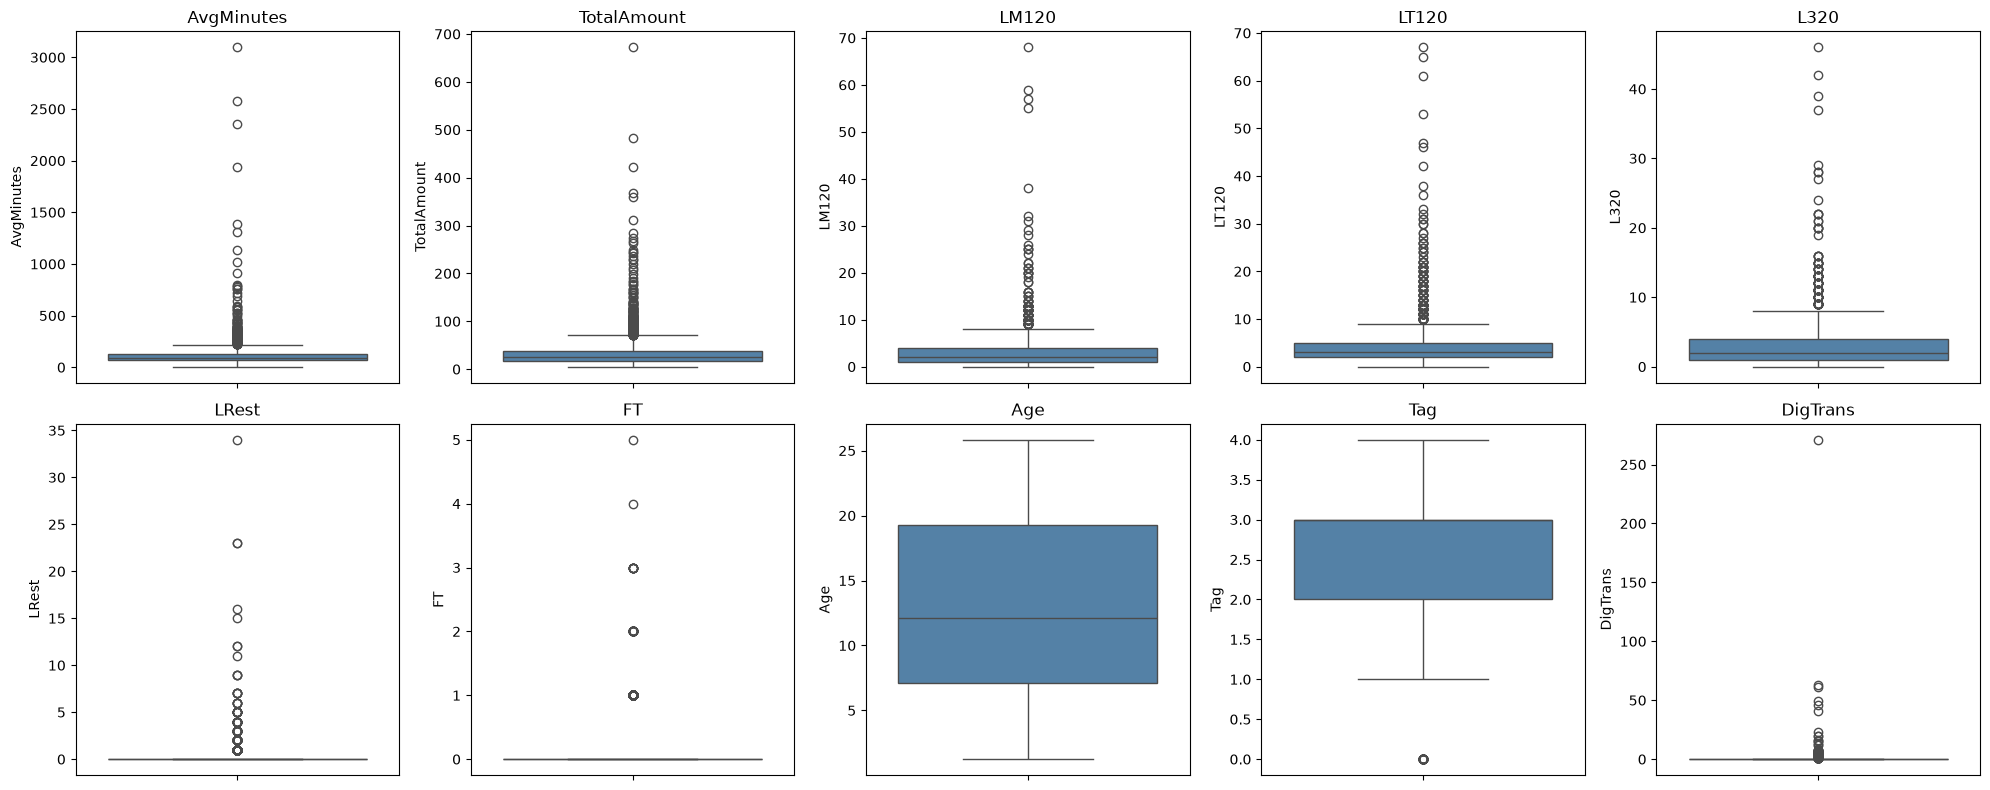

In [119]:
numeric_cols = df.drop(['plate'], axis=1).select_dtypes(include=np.number).columns

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [120]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness)

DigTrans       39.397355
AvgMinutes     12.221663
LRest          11.621156
TotalAmount     6.304392
LM120           6.221737
LT120           4.862226
FT              4.487967
L320            4.209155
Age             0.127613
Tag            -0.407137
dtype: float64


In [121]:
df_treated = df.copy()

# Variables zero-inflated: importa más si hubo actividad que la magnitud exacta
zero_inflated_cols = ['LRest', 'FT', 'DigTrans']
for col in zero_inflated_cols:
    df_treated[col + '_flag'] = (df_treated[col] > 0).astype(int)

df_treated = df_treated.drop(columns=zero_inflated_cols)


In [122]:
def cap_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower=lower, upper=upper)

flag_cols = ['LRest_flag', 'FT_flag', 'DigTrans_flag']
cols_to_cap = df_treated.drop(['plate'] + flag_cols, axis=1).select_dtypes(include=np.number).columns

for col in cols_to_cap:
    df_treated[col] = cap_outliers_iqr(df_treated[col])

In [123]:
df_treated[cols_to_cap].skew().sort_values(ascending=False)

L320           1.104722
TotalAmount    1.046526
AvgMinutes     0.925980
LM120          0.833592
LT120          0.615483
Age            0.127613
Tag           -0.264010
dtype: float64

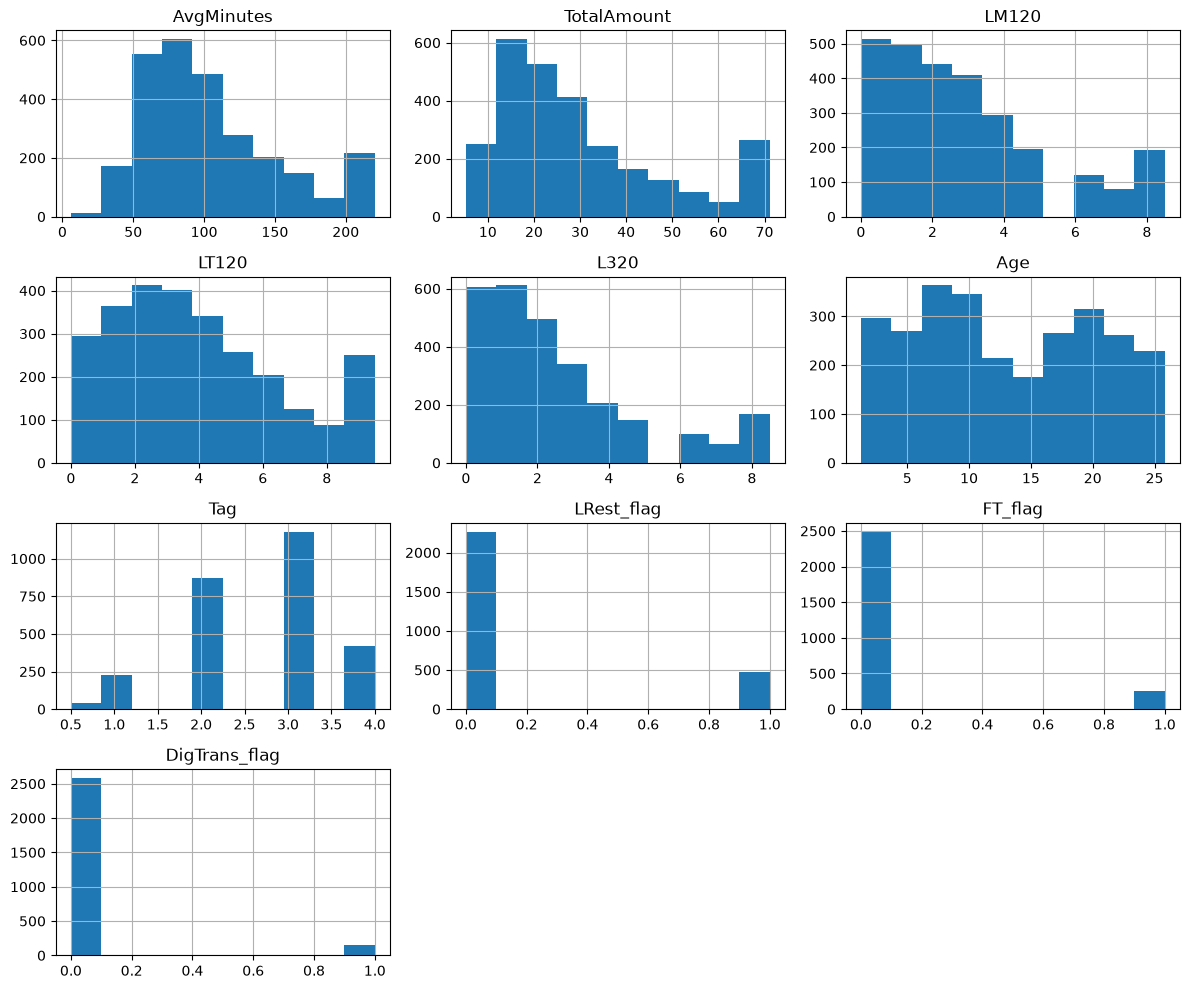

In [124]:
df_treated.drop('plate', axis=1).hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [125]:
X = df_treated.drop('plate', axis=1)

scaler = StandardScaler()
scaler.fit(X)

X_scaled = scaler.transform(X)

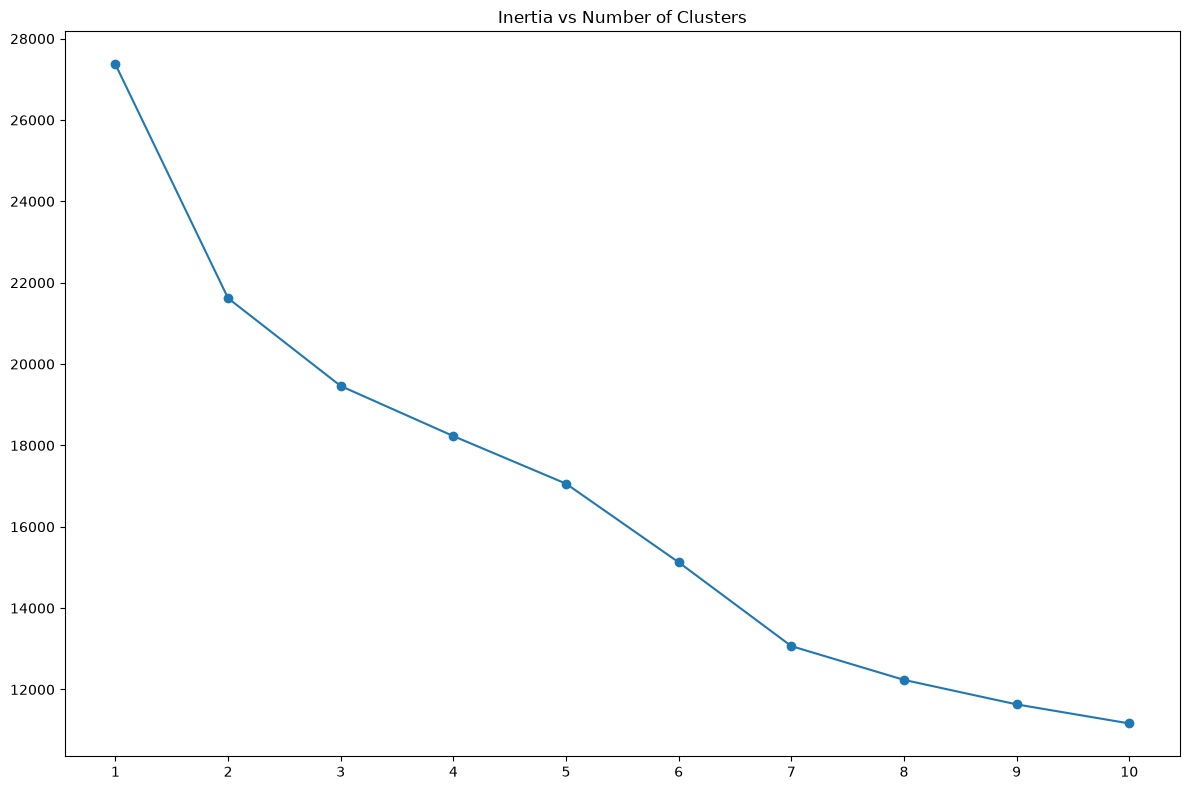

In [126]:
X = pd.DataFrame(X_scaled)
inertias = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    y = model.fit_predict(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(12, 8))
plt.plot(range(1, 11), inertias, marker='o')
plt.xticks(ticks=range(1, 11), labels=range(1, 11))
plt.title('Inertia vs Number of Clusters')

plt.tight_layout()
plt.show()

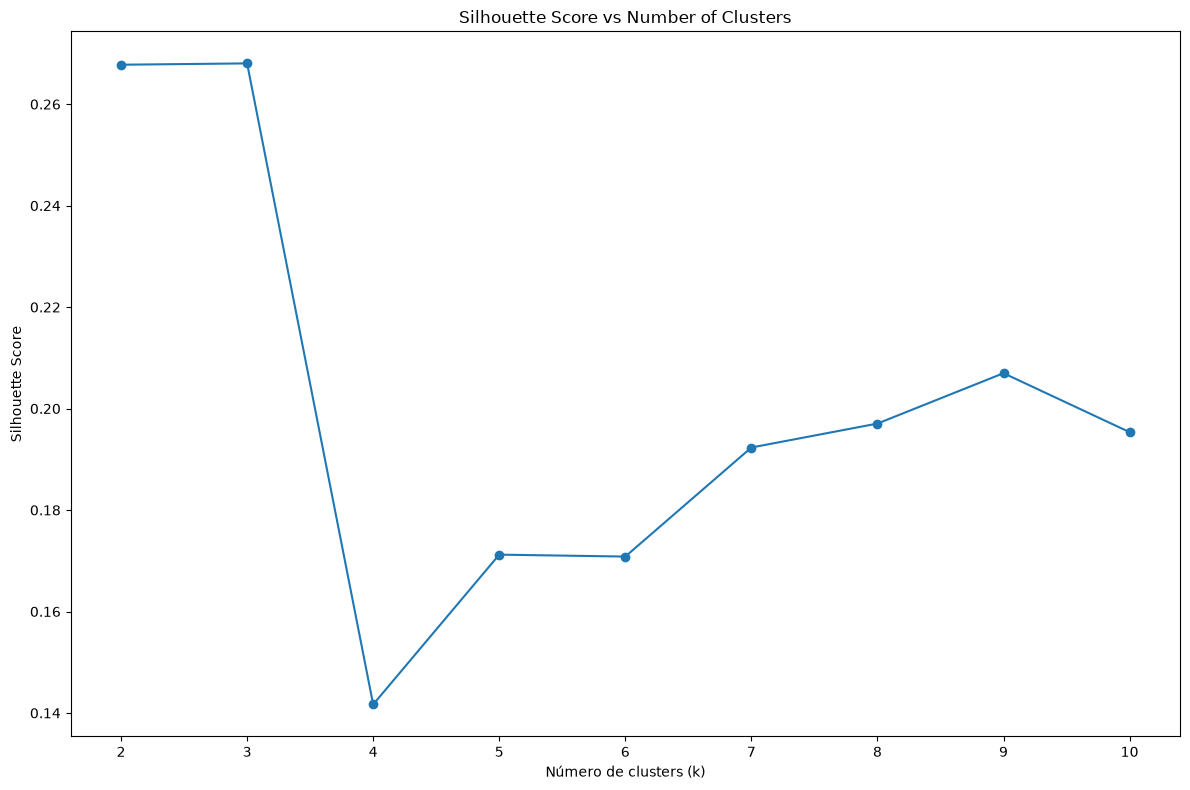

k=2: silhouette=0.2678
k=3: silhouette=0.2680
k=4: silhouette=0.1417
k=5: silhouette=0.1712
k=6: silhouette=0.1708
k=7: silhouette=0.1923
k=8: silhouette=0.1970
k=9: silhouette=0.2070
k=10: silhouette=0.1954


In [127]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):  # silhouette no está definido para k=1
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 8))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xticks(ticks=range(2, 11), labels=range(2, 11))
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.tight_layout()
plt.show()

for k, s in zip(range(2, 11), sil_scores):
    print(f'k={k}: silhouette={s:.4f}')

In [128]:
model = KMeans(n_clusters=8, random_state=42, n_init='auto')
y = model.fit_predict(X_scaled)

# Adding the cluster assignments to our original dataframe
df_treated['CLUSTER'] = y + 1  # Adding 1 to make clusters 1-based instead of 0-based
# df.head()

In [129]:
df_treated['CLUSTER'].value_counts()

CLUSTER
5    616
1    594
8    341
4    333
2    311
7    224
6    167
3    151
Name: count, dtype: int64

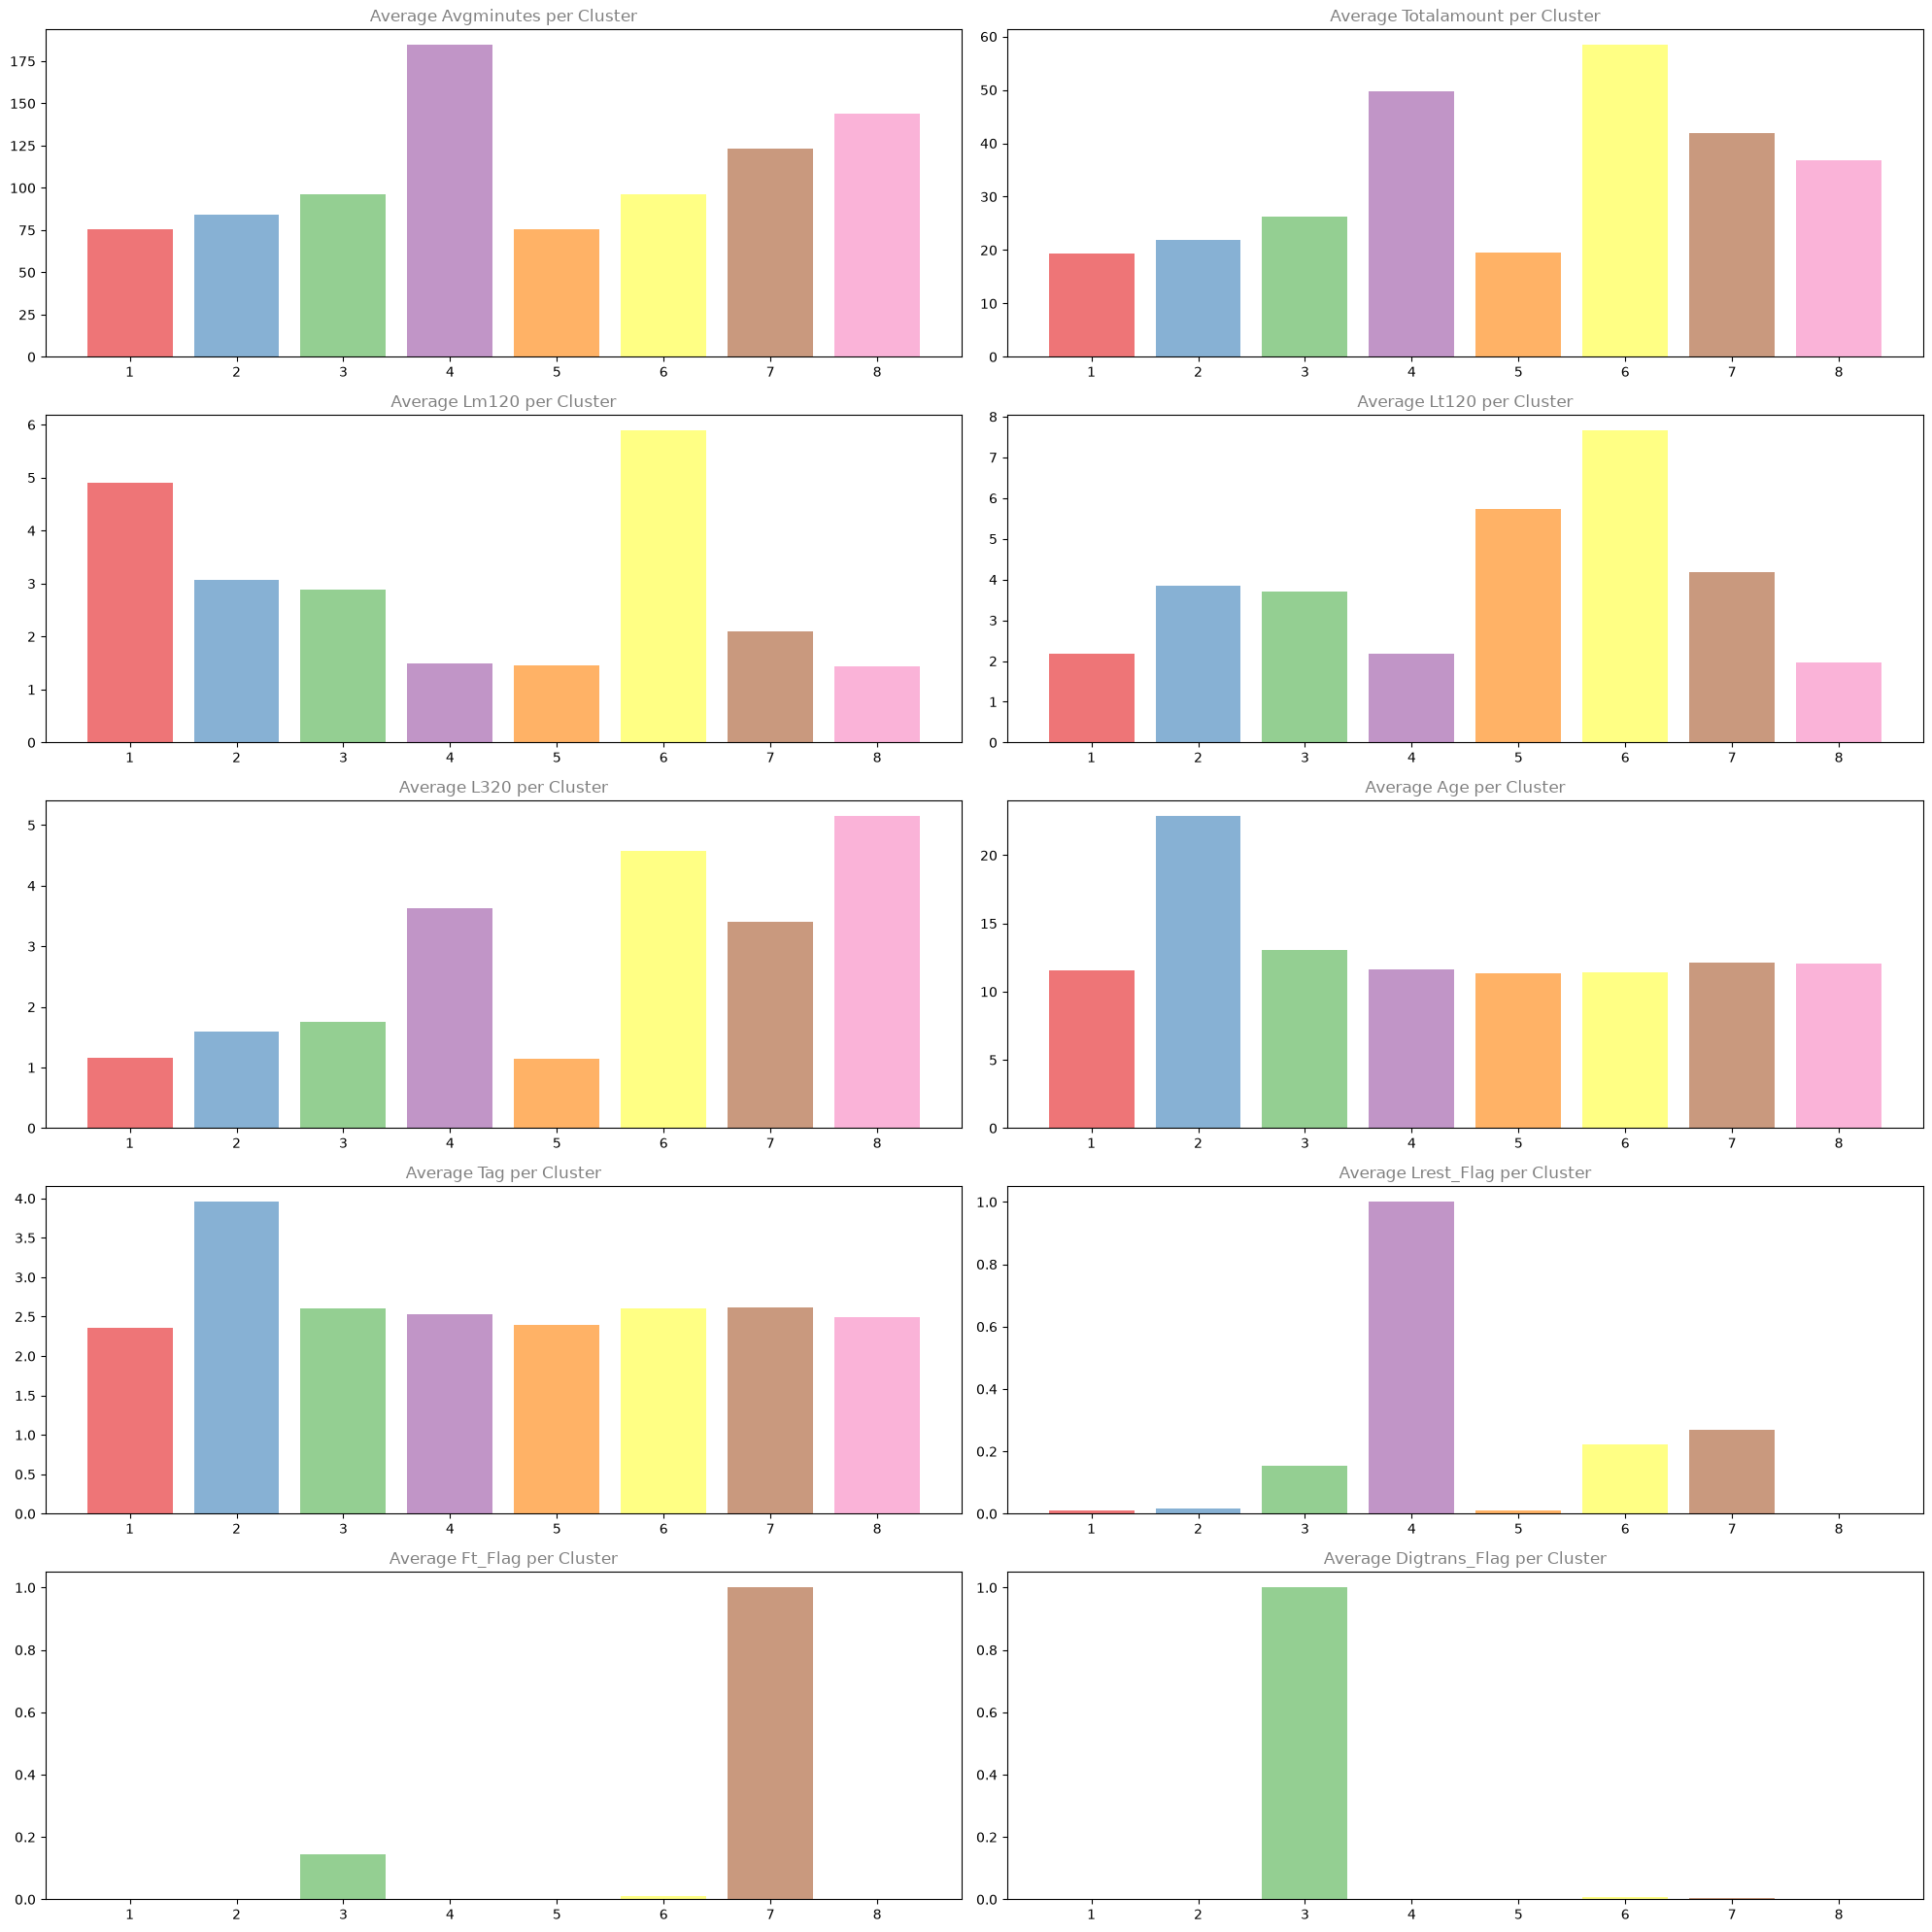

In [130]:
numeric_columns = df_treated.select_dtypes(include=np.number).drop(['CLUSTER'], axis=1).columns

fig = plt.figure(figsize=(20, 20))
for i, column in enumerate(numeric_columns):
    df_plot = df_treated.groupby('CLUSTER')[column].mean()
    ax = fig.add_subplot(5, 2, i+1)
    ax.bar(df_plot.index, df_plot, color=sns.color_palette('Set1'), alpha=0.6)
    ax.set_title(f'Average {column.title()} per Cluster', alpha=0.5)
    ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

In [131]:
df_treated.groupby('CLUSTER')[numeric_columns].mean().round(2)

,AvgMinutes,TotalAmount,LM120,LT120,L320,Age,Tag,LRest_flag,FT_flag,DigTrans_flag
CLUSTER,,,,,,,,,,
1,75.53,19.32,4.90,2.19,1.15,11.57,2.35,0.01,0.00,0.00
2,83.88,21.94,3.07,3.86,1.59,22.85,3.95,0.02,0.00,0.00
3,96.44,26.21,2.89,3.70,1.75,13.08,2.61,0.15,0.15,1.00
4,184.52,49.68,1.49,2.17,3.63,11.66,2.53,1.00,0.00,0.00
5,75.63,19.56,1.45,5.73,1.14,11.35,2.39,0.01,0.00,0.00
6,96.03,58.40,5.89,7.66,4.57,11.43,2.61,0.22,0.01,0.01
7,123.20,41.90,2.10,4.19,3.41,12.11,2.62,0.27,1.00,0.00
8,144.04,36.82,1.44,1.96,5.15,12.03,2.49,0.00,0.00,0.00


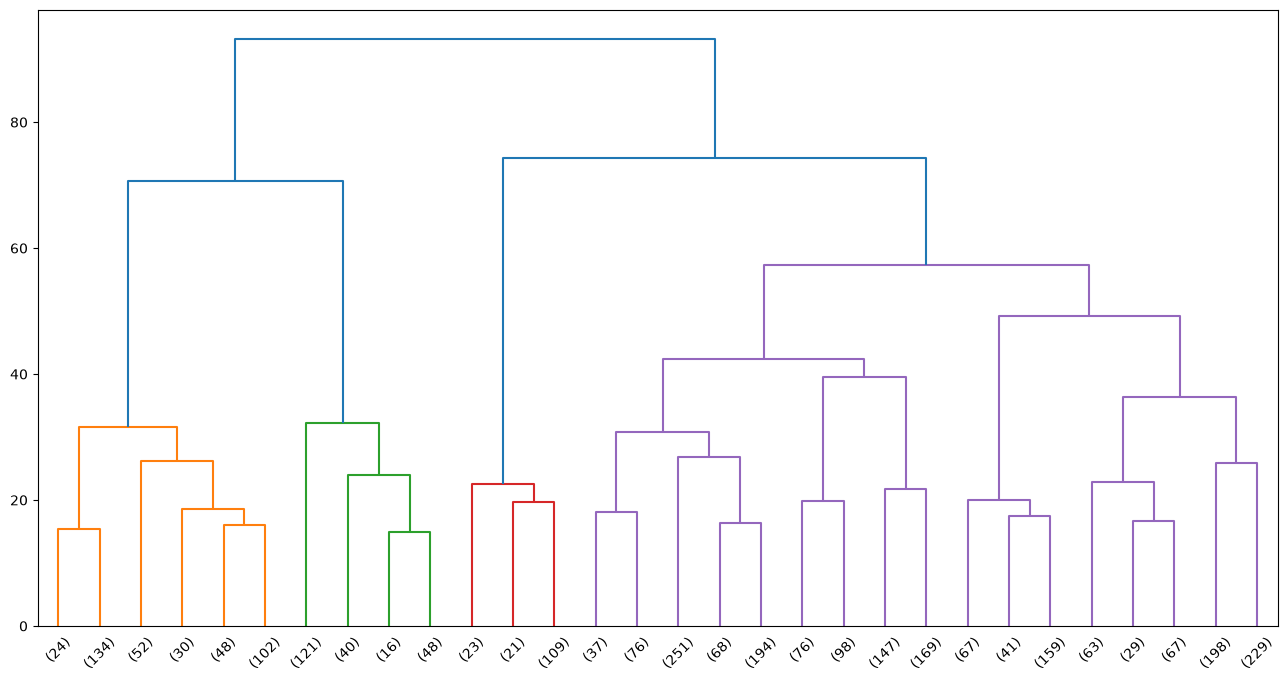

In [132]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(16, 8))
#dendrogram(Z, truncate_mode='level', p=8)
dendrogram(Z, truncate_mode='lastp', p=30)
plt.show()

In [133]:
from kmodes.kprototypes import KPrototypes

feature_cols = df_treated.drop('plate', axis=1).columns.tolist()
X_kproto = df_treated[feature_cols].copy()

categorical_cols = ['LRest_flag', 'FT_flag', 'DigTrans_flag', 'Tag']
categorical_idx = [feature_cols.index(c) for c in categorical_cols]

kproto = KPrototypes(n_clusters=8, random_state=42, n_init=5)
clusters = kproto.fit_predict(X_kproto.values, categorical=categorical_idx)

df_treated['CLUSTER_KPROTO'] = clusters + 1

[np.float64(2778967.27953389), np.float64(1628770.5197357703), np.float64(1174237.6226322118), np.float64(975302.7334057391), np.float64(805814.9063278645), np.float64(710157.411626772), np.float64(641405.6001826724), np.float64(580492.9044947998), np.float64(533065.2147059916)]


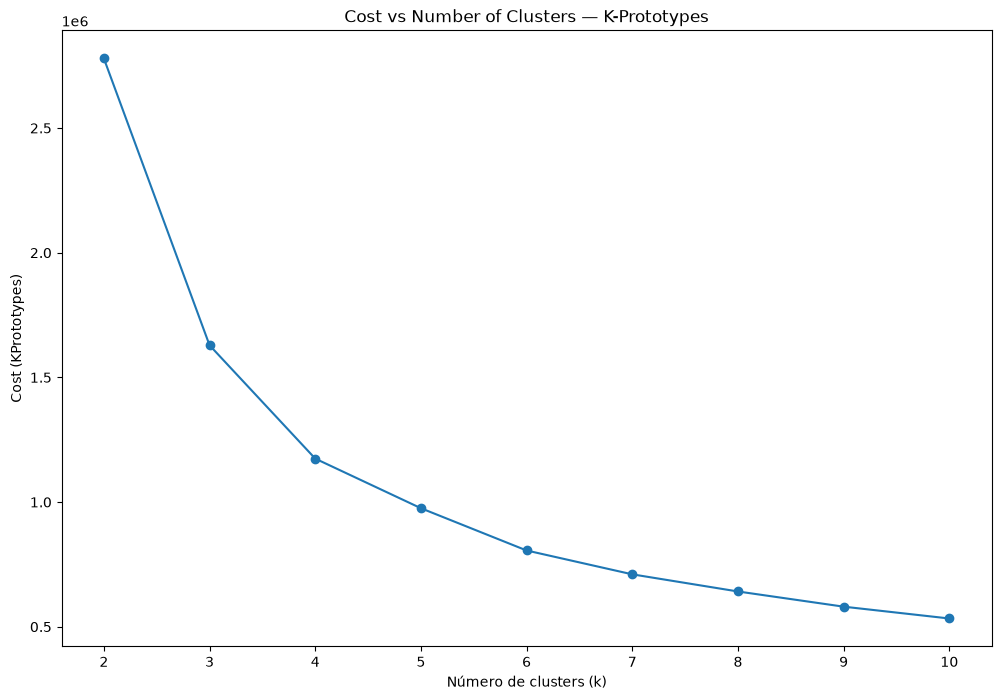

In [134]:
costs = []
for k in range(2, 11):
    kp = KPrototypes(n_clusters=k, random_state=42, n_init=5)
    kp.fit_predict(X_kproto.values, categorical=categorical_idx)
    costs.append(kp.cost_)

print(costs)

plt.figure(figsize=(12, 8))
plt.plot(range(2, 11), costs, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Cost (KPrototypes)')
plt.title('Cost vs Number of Clusters — K-Prototypes')
plt.show()

In [135]:
df_treated.groupby('CLUSTER_KPROTO')[feature_cols].mean(numeric_only=True).round(2)
df_treated['CLUSTER_KPROTO'].value_counts()

CLUSTER_KPROTO
3    658
7    582
1    418
2    324
5    242
8    220
4    160
6    133
Name: count, dtype: int64

In [136]:
pd.crosstab(df_treated['CLUSTER'], df_treated['CLUSTER_KPROTO'])

CLUSTER_KPROTO,1,2,3,4,5,6,7,8
CLUSTER,,,,,,,,
1,165,25,223,16,0,0,165,0
2,61,35,102,12,2,3,95,1
3,29,15,48,6,9,4,29,11
4,0,50,0,0,169,15,13,86
5,152,16,245,9,0,1,193,0
6,3,1,4,91,2,59,4,3
7,8,22,36,26,35,28,40,29
8,0,160,0,0,25,23,43,90
